# Overfitting, Underfitting, Bias-Variance, and Learning Curves

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Import Scikit-Learn modules

In [2]:
from sklearn.datasets import make_regression,make_classification
from sklearn.model_selection import train_test_split,learning_curve
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression,LogisticRegression,Ridge
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
     mean_squared_error,
     r2_score,
     accuracy_score,
     classification_report
)


## NonLinear Regression Data

### Creation of Dataset

In [3]:
np.random.seed(42)
x = np.sort(6 * np.random.rand(250, 1), axis=0)
y = np.sin(x).ravel() + 0.2 * np.random.randn(250)

### Train and Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.25,
    random_state=42
)

### Data Visualise

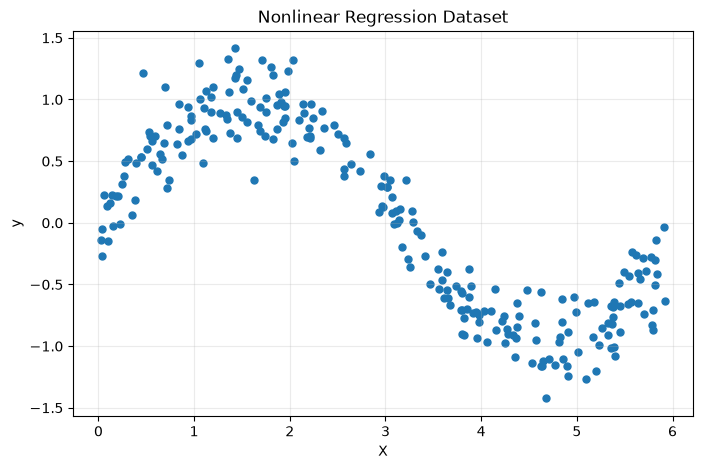

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=25)
plt.title("Nonlinear Regression Dataset")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(alpha=0.25)
plt.show()

## Training Models with Different Complexity

In [6]:
models = {
    "Underfit: Linear Regression": LinearRegression(),

    "Good Fit: Polynomial Degree 3": Pipeline([
        ("poly", PolynomialFeatures(degree=3, include_bias=False)),
        ("model", LinearRegression())
    ]),

    "Overfit: Polynomial Degree 20": Pipeline([
        ("poly", PolynomialFeatures(degree=20, include_bias=False)),
        ("model", LinearRegression())
    ]),

    "Regularized Polynomial Degree 20": Pipeline([
        ("poly", PolynomialFeatures(degree=20, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=10))
    ])
}

## Regression Model Evaluation

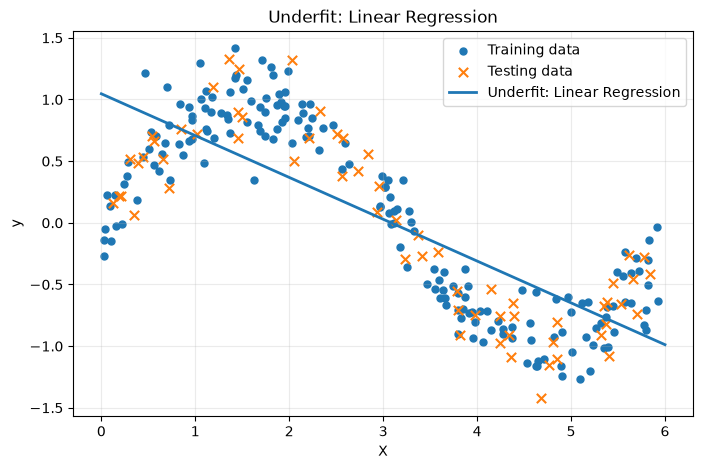

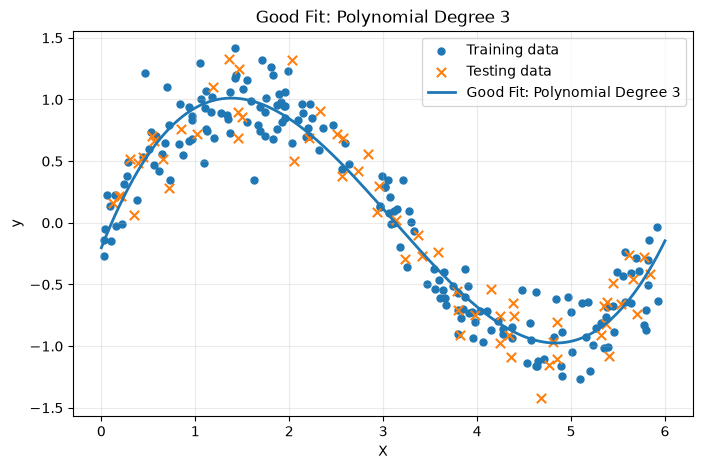

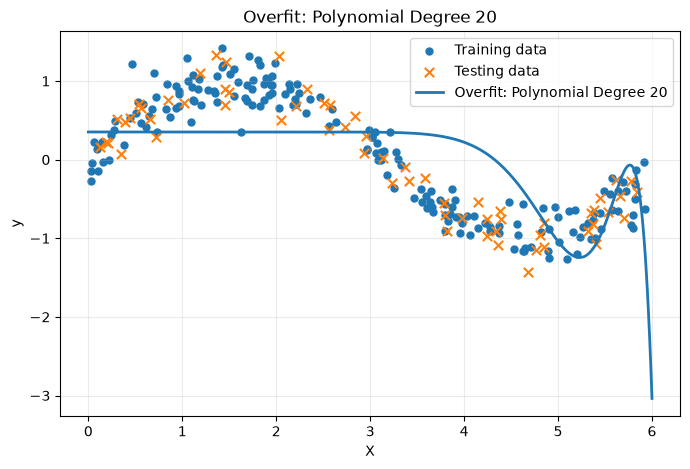

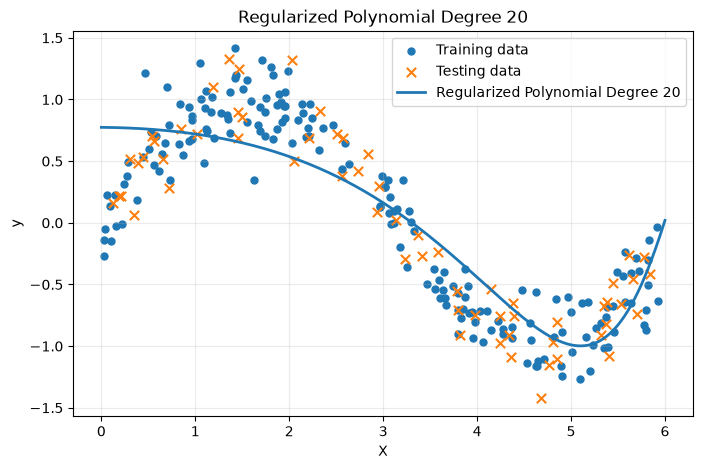

,model,train_RMSE,test_RMSE,RMSE_gap,train_R2,test_R2
1,Good Fit: Polynomial Degree 3,0.206278,0.203426,-0.002852,0.925926,0.921656
3,Regularized Polynomial Degree 20,0.346887,0.322246,-0.024641,0.790524,0.803408
0,Underfit: Linear Regression,0.466163,0.452811,-0.013352,0.621702,0.611827
2,Overfit: Polynomial Degree 20,0.574815,0.544212,-0.030602,0.424807,0.439303


In [7]:
results = []
X_plot = np.linspace(0, 6, 500).reshape(-1, 1)
for name, model in models.items():
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_plot = model.predict(X_plot)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    results.append({
        "model": name,
        "train_RMSE": train_rmse,
        "test_RMSE": test_rmse,
        "RMSE_gap": test_rmse - train_rmse,
        "train_R2": r2_score(y_train, y_train_pred),
        "test_R2": r2_score(y_test, y_test_pred)
    })
    plt.figure(figsize=(8, 5))
    plt.scatter(X_train, y_train, s=25, label="Training data")
    plt.scatter(X_test, y_test, s=45, marker="x", label="Testing data")
    plt.plot(X_plot, y_plot, linewidth=2, label=name)
    plt.title(name)
    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()
results_df = pd.DataFrame(results)
display(results_df.sort_values(by="test_RMSE"))

### 10. Decision Tree Complexity

In [8]:
depth_values = [1, 2, 3, 5, 10, None]
tree_results = []
for depth in depth_values:
    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    tree_results.append({
        "max_depth": depth,
        "train_RMSE": train_rmse,
        "test_RMSE": test_rmse,
        "RMSE_gap": test_rmse - train_rmse,
        "train_R2": r2_score(y_train, y_train_pred),
        "test_R2": r2_score(y_test, y_test_pred)
    })
tree_results_df = pd.DataFrame(tree_results)
display(tree_results_df)

,max_depth,train_RMSE,test_RMSE,RMSE_gap,train_R2,test_R2
0,1.0,0.348066,0.331285,-0.016781,0.789098,0.792224
1,2.0,0.296151,0.291149,-0.005003,0.847319,0.839520
2,3.0,0.210795,0.242526,0.031732,0.922647,0.888645
3,5.0,0.169871,0.223622,0.053751,0.949766,0.905328
4,10.0,0.074645,0.250923,0.176278,0.990300,0.880801
5,NaN,0.000000,0.256351,0.256351,1.000000,0.875589


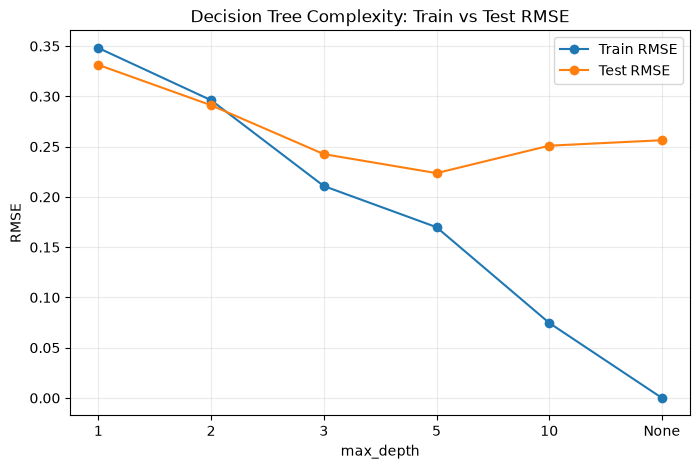

In [14]:
plot_df = tree_results_df.copy()
plot_df["max_depth_label"] = plot_df["max_depth"].apply(
    lambda x: "None" if pd.isna(x) else str(int(x))
)
plt.figure(figsize=(8, 5))
plt.plot(plot_df["max_depth_label"], plot_df["train_RMSE"], marker="o", label="Train RMSE")
plt.plot(plot_df["max_depth_label"], plot_df["test_RMSE"], marker="o", label="Test RMSE")
plt.title("Decision Tree Complexity: Train vs Test RMSE")
plt.xlabel("max_depth")
plt.ylabel("RMSE")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

### Classification Example

### Classification Dataset

In [15]:
X_cls, y_cls = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=8,
    n_redundant=5,
    class_sep=1.0,
    random_state=42
)

X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls,
    y_cls,
    test_size=0.25,
    stratify=y_cls,
    random_state=42
)

### Classification Models

In [16]:
classification_models = {
    "Underfit: Shallow Tree": DecisionTreeClassifier(
        max_depth=1,
        random_state=42
    ),

    "Possible Good Fit: Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=3000))
    ]),

    "Possible Overfit: Deep Tree": DecisionTreeClassifier(
        max_depth=None,
        random_state=42
    ),

    "Regularized SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=1, gamma="scale"))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        random_state=42
    )
}

### Evaluate the Classification Models

In [17]:
cls_results = []

for name, model in classification_models.items():
    model.fit(X_cls_train, y_cls_train)

    y_train_pred = model.predict(X_cls_train)
    y_test_pred = model.predict(X_cls_test)

    train_acc = accuracy_score(y_cls_train, y_train_pred)
    test_acc = accuracy_score(y_cls_test, y_test_pred)

    cls_results.append({
        "model": name,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "generalization_gap": train_acc - test_acc
    })

cls_results_df = pd.DataFrame(cls_results)
display(cls_results_df.sort_values(by="test_accuracy", ascending=False))

,model,train_accuracy,test_accuracy,generalization_gap
4,Random Forest,0.994667,0.884,0.110667
3,Regularized SVM,0.949333,0.884,0.065333
2,Possible Overfit: Deep Tree,1.000000,0.756,0.244000
1,Possible Good Fit: Logistic Regression,0.705333,0.676,0.029333
0,Underfit: Shallow Tree,0.640000,0.664,-0.024000


### Learning Curve Function

In [18]:
def plot_learning_curve(model, X, y, title, scoring="accuracy"):
    train_sizes, train_scores, validation_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        train_sizes=np.linspace(0.1, 1.0, 5),
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)

    validation_mean = validation_scores.mean(axis=1)
    validation_std = validation_scores.std(axis=1)

    plt.figure(figsize=(8, 5))

    plt.plot(
        train_sizes,
        train_mean,
        marker="o",
        label="Training score"
    )

    plt.plot(
        train_sizes,
        validation_mean,
        marker="o",
        label="Validation score"
    )

    plt.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.15
    )

    plt.fill_between(
        train_sizes,
        validation_mean - validation_std,
        validation_mean + validation_std,
        alpha=0.15
    )

    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel(scoring)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

### Underfitting Learning Curve

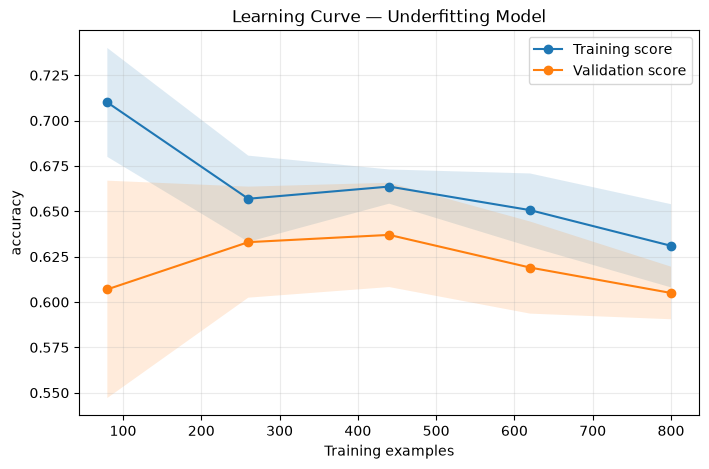

In [19]:
underfit_model = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

plot_learning_curve(
    underfit_model,
    X_cls,
    y_cls,
    title="Learning Curve — Underfitting Model",
    scoring="accuracy"
)

### Overfitting Learning Curve

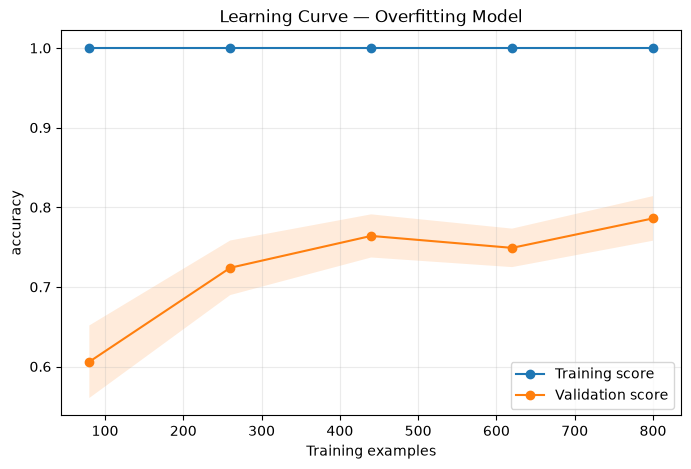

In [20]:
overfit_model = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

plot_learning_curve(
    overfit_model,
    X_cls,
    y_cls,
    title="Learning Curve — Overfitting Model",
    scoring="accuracy"
)

### Better Fit learning Curve

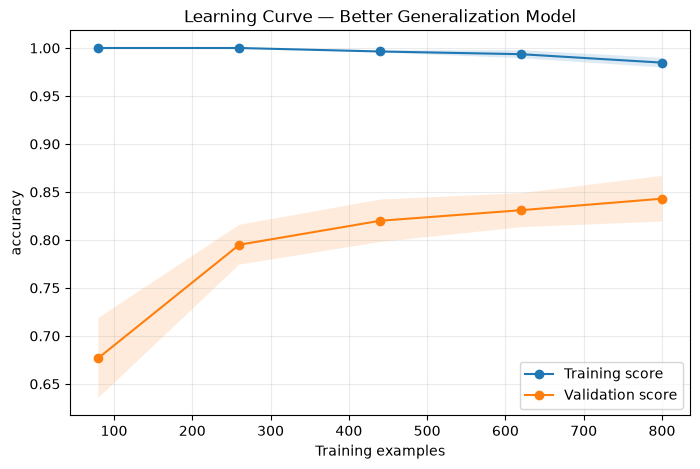

In [22]:
better_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)
plot_learning_curve(
    better_model,
    X_cls,
    y_cls,
    title="Learning Curve — Better Generalization Model",
    scoring="accuracy"
)